In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

ModuleNotFoundError: No module named 'numpy'

In [ ]:
df = pd.read_csv("qoute_dataset.csv")

In [ ]:
df.head()

,quote,Author
0,“The world as we have created it is a process ...,Albert Einstein
1,"“It is our choices, Harry, that show what we t...",J.K. Rowling
2,“There are only two ways to live your life. On...,Albert Einstein
3,"“The person, be it gentleman or lady, who has ...",Jane Austen
4,"“Imperfection is beauty, madness is genius and...",Marilyn Monroe


In [ ]:
df.shape

(3038, 2)

In [ ]:
quotes = df["quote"]
quotes.head()

,quote
0,“The world as we have created it is a process ...
1,"“It is our choices, Harry, that show what we t..."
2,“There are only two ways to live your life. On...
3,"“The person, be it gentleman or lady, who has ..."
4,"“Imperfection is beauty, madness is genius and..."


In [ ]:
quotes = quotes.str.lower()

In [ ]:
import string
translator = str.maketrans('', '', string.punctuation)
quotes = quotes.apply(lambda x: x.translate(translator))

In [ ]:
quotes.head()

,quote
0,“the world as we have created it is a process ...
1,“it is our choices harry that show what we tru...
2,“there are only two ways to live your life one...
3,“the person be it gentleman or lady who has no...
4,“imperfection is beauty madness is genius and ...


In [ ]:
from tensorflow.keras.preprocessing.text import Tokenizer

In [ ]:
vocab_size = 10000

tokenizer = Tokenizer(num_words=vocab_size)
tokenizer.fit_on_texts(quotes)

In [ ]:
word_index = tokenizer.word_index
print(len(word_index))
list(word_index.items())[:10]

8978


[('the', 1),
 ('you', 2),
 ('to', 3),
 ('and', 4),
 ('a', 5),
 ('i', 6),
 ('is', 7),
 ('of', 8),
 ('that', 9),
 ('it', 10)]

In [ ]:
sequence = tokenizer.texts_to_sequences(quotes)

In [ ]:
quotes[0]

'“the world as we have created it is a process of our thinking it cannot be changed without changing our thinking”'

In [ ]:
sequence[0]

[713,
 62,
 29,
 19,
 16,
 946,
 10,
 7,
 5,
 1156,
 8,
 70,
 293,
 10,
 145,
 12,
 809,
 104,
 752,
 70,
 2461]

In [ ]:
X = []
y = []

for seq in sequence:
  for i in range(1, len(seq)):
    input_seq = seq[:i]
    output_seq = seq[i]
    X.append(input_seq)
    y.append(output_seq)

In [ ]:
X

[[713],
 [713, 62],
 [713, 62, 29],
 [713, 62, 29, 19],
 [713, 62, 29, 19, 16],
 [713, 62, 29, 19, 16, 946],
 [713, 62, 29, 19, 16, 946, 10],
 [713, 62, 29, 19, 16, 946, 10, 7],
 [713, 62, 29, 19, 16, 946, 10, 7, 5],
 [713, 62, 29, 19, 16, 946, 10, 7, 5, 1156],
 [713, 62, 29, 19, 16, 946, 10, 7, 5, 1156, 8],
 [713, 62, 29, 19, 16, 946, 10, 7, 5, 1156, 8, 70],
 [713, 62, 29, 19, 16, 946, 10, 7, 5, 1156, 8, 70, 293],
 [713, 62, 29, 19, 16, 946, 10, 7, 5, 1156, 8, 70, 293, 10],
 [713, 62, 29, 19, 16, 946, 10, 7, 5, 1156, 8, 70, 293, 10, 145],
 [713, 62, 29, 19, 16, 946, 10, 7, 5, 1156, 8, 70, 293, 10, 145, 12],
 [713, 62, 29, 19, 16, 946, 10, 7, 5, 1156, 8, 70, 293, 10, 145, 12, 809],
 [713, 62, 29, 19, 16, 946, 10, 7, 5, 1156, 8, 70, 293, 10, 145, 12, 809, 104],
 [713,
  62,
  29,
  19,
  16,
  946,
  10,
  7,
  5,
  1156,
  8,
  70,
  293,
  10,
  145,
  12,
  809,
  104,
  752],
 [713,
  62,
  29,
  19,
  16,
  946,
  10,
  7,
  5,
  1156,
  8,
  70,
  293,
  10,
  145,
  12,
  809,
  

In [ ]:
y

[62,
 29,
 19,
 16,
 946,
 10,
 7,
 5,
 1156,
 8,
 70,
 293,
 10,
 145,
 12,
 809,
 104,
 752,
 70,
 2461,
 7,
 70,
 871,
 373,
 9,
 433,
 21,
 19,
 465,
 14,
 294,
 52,
 54,
 70,
 3676,
 14,
 53,
 201,
 714,
 3,
 81,
 15,
 36,
 37,
 7,
 29,
 329,
 93,
 7,
 5,
 1157,
 1,
 101,
 7,
 29,
 329,
 126,
 7,
 5,
 3677,
 116,
 12,
 10,
 2462,
 32,
 1043,
 30,
 82,
 13,
 601,
 11,
 5,
 74,
 1338,
 119,
 12,
 2463,
 3678,
 7,
 313,
 753,
 7,
 638,
 4,
 43,
 144,
 3,
 12,
 682,
 1339,
 54,
 682,
 3680,
 13,
 3,
 202,
 5,
 90,
 8,
 434,
 279,
 202,
 5,
 90,
 8,
 3682,
 7,
 144,
 3,
 12,
 1340,
 17,
 21,
 2,
 14,
 54,
 3,
 12,
 175,
 17,
 21,
 2,
 14,
 3683,
 16,
 13,
 1341,
 191,
 51,
 415,
 2464,
 714,
 9,
 363,
 3684,
 180,
 7,
 39,
 5,
 810,
 1342,
 2,
 46,
 50,
 59,
 322,
 10,
 7,
 168,
 43,
 11,
 639,
 3685,
 111,
 104,
 1045,
 7,
 39,
 2,
 50,
 3686,
 36,
 7,
 21,
 2,
 65,
 10,
 47,
 181,
 21,
 96,
 130,
 3,
 754,
 58,
 123,
 43,
 5,
 1939,
 174,
 18,
 1,
 74,
 208,
 7,
 2,
 94,
 3,
 466,
 5

In [ ]:
print(len(X))
print(len(y))

85271
85271


In [ ]:
max_len = max(len(x) for x in X)
print(max_len)

745


In [ ]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

X_padded = pad_sequences(X, maxlen=max_len, padding="pre")

In [ ]:
X_padded[0]

array([  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   

In [ ]:
y = np.array(y)

In [ ]:
X_padded.shape

(85271, 745)

In [ ]:
y

array([ 62,  29,  19, ...,   3, 169, 101])

In [ ]:
from tensorflow.keras.utils import to_categorical
y_one_hot = to_categorical(y, num_classes=vocab_size)

In [ ]:
print(y.shape)
print(y_one_hot.shape)

(85271,)
(85271, 10000)


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, Dense

In [ ]:
embedding_dim = 50
rnn_units = 256

In [ ]:
rnn_model = Sequential()

rnn_model.add(
    Embedding(input_dim=vocab_size, output_dim=embedding_dim,input_length=max_len)
)

rnn_model.add(
    SimpleRNN(units=rnn_units)
)

rnn_model.add(
    Dense(units=vocab_size, activation="softmax")
)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [ ]:
rnn_model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
rnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dropout

lstm_model = Sequential()

lstm_model.add(
    Embedding(input_dim=vocab_size, output_dim=embedding_dim,input_length=max_len)
)

lstm_model.add(
    LSTM(units=rnn_units)
)

lstm_model.add(Dropout(0.2))

lstm_model.add(
    Dense(units=vocab_size, activation="softmax")
)

In [ ]:
lstm_model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
lstm_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

In [ ]:
epochs = 10
batch_size = 128

history_rnn = rnn_model.fit(
    X_padded,y_one_hot,epochs=epochs,batch_size=batch_size, validation_split=0.1,
    callbacks=[early_stopping]
)

Epoch 1/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 55s 83ms/step - accuracy: 0.0369 - loss: 6.8916 - val_accuracy: 0.0454 - val_loss: 6.8788
Epoch 2/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 46s 76ms/step - accuracy: 0.0541 - loss: 6.5250 - val_accuracy: 0.0000e+00 - val_loss: 11.1448
Epoch 3/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 45s 75ms/step - accuracy: 0.0615 - loss: 6.4838 - val_accuracy: 0.0754 - val_loss: 6.9735
Epoch 4/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 45s 75ms/step - accuracy: 0.0860 - loss: 6.1790 - val_accuracy: 0.0881 - val_loss: 6.6140
Epoch 5/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 45s 75ms/step - accuracy: 0.0999 - loss: 6.0112 - val_accuracy: 0.0913 - val_loss: 6.5477
Epoch 6/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 45s 76ms/step - accuracy: 0.1109 - loss: 5.7743 - val_accuracy: 0.0958 - val_loss: 6.4778
Epoch 7/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 45s 76ms/step - accuracy: 0.1230 - loss: 5.5635 - val_accuracy: 0.1008 - val_loss: 6.4765
Epoch 8/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 46s 76ms/step - accuracy: 0.1334 - loss: 5.36

In [ ]:
epochs = 100
batch_size = 128

history_lstm = lstm_model.fit(
    X_padded,
    y_one_hot,
    epochs=epochs,
    batch_size=batch_size,
    validation_split=0.1,
    callbacks=[early_stopping]
)

Epoch 1/100
600/600 ━━━━━━━━━━━━━━━━━━━━ 72s 108ms/step - accuracy: 0.0415 - loss: 6.7084 - val_accuracy: 0.0490 - val_loss: 6.6079
Epoch 2/100
600/600 ━━━━━━━━━━━━━━━━━━━━ 64s 107ms/step - accuracy: 0.0614 - loss: 6.2908 - val_accuracy: 0.0686 - val_loss: 6.4500
Epoch 3/100
600/600 ━━━━━━━━━━━━━━━━━━━━ 64s 106ms/step - accuracy: 0.0862 - loss: 5.9944 - val_accuracy: 0.0951 - val_loss: 6.3585
Epoch 4/100
600/600 ━━━━━━━━━━━━━━━━━━━━ 64s 107ms/step - accuracy: 0.1059 - loss: 5.7229 - val_accuracy: 0.1015 - val_loss: 6.3166
Epoch 5/100
600/600 ━━━━━━━━━━━━━━━━━━━━ 64s 107ms/step - accuracy: 0.1185 - loss: 5.4781 - val_accuracy: 0.1091 - val_loss: 6.3418
Epoch 6/100
600/600 ━━━━━━━━━━━━━━━━━━━━ 64s 106ms/step - accuracy: 0.1262 - loss: 5.2497 - val_accuracy: 0.1092 - val_loss: 6.3894
Epoch 7/100
600/600 ━━━━━━━━━━━━━━━━━━━━ 82s 107ms/step - accuracy: 0.1383 - loss: 5.0287 - val_accuracy: 0.1106 - val_loss: 6.4528
Epoch 8/100
600/600 ━━━━━━━━━━━━━━━━━━━━ 66s 110ms/step - accuracy: 0.1471 -

## Next Steps: Improving the Text Generation Model

To make this model more robust and suitable for a resume project, we'll explore several advanced techniques. A key area for improvement is the model architecture. We will start by adding another LSTM layer to increase the model's capacity to learn complex patterns.

### Proposed Architectural Change: Stacked LSTM

Stacked LSTMs are a common and effective way to improve the performance of sequence models. By adding a second LSTM layer, the model can learn a hierarchical representation of the input sequence, where the first layer captures lower-level features and the second layer captures higher-level, more abstract features.

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

stacked_lstm_model = Sequential()

stacked_lstm_model.add(
    Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=max_len)
)

stacked_lstm_model.add(
    LSTM(units=rnn_units, return_sequences=True)
)
stacked_lstm_model.add(Dropout(0.2))

stacked_lstm_model.add(
    LSTM(units=rnn_units)
)
stacked_lstm_model.add(Dropout(0.2))

stacked_lstm_model.add(
    Dense(units=vocab_size, activation="softmax")
)

stacked_lstm_model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

stacked_lstm_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
epochs = 100
batch_size = 128

early_stopping_stacked = EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True
)

history_stacked_lstm = stacked_lstm_model.fit(
    X_padded,
    y_one_hot,
    epochs=epochs,
    batch_size=batch_size,
    validation_split=0.1,
    callbacks=[early_stopping_stacked]
)

Epoch 1/100
600/600 ━━━━━━━━━━━━━━━━━━━━ 145s 236ms/step - accuracy: 0.0358 - loss: 6.8120 - val_accuracy: 0.0365 - val_loss: 6.6722
Epoch 2/100
600/600 ━━━━━━━━━━━━━━━━━━━━ 144s 240ms/step - accuracy: 0.0504 - loss: 6.4223 - val_accuracy: 0.0531 - val_loss: 6.6120
Epoch 3/100
430/600 ━━━━━━━━━━━━━━━━━━━━ 39s 230ms/step - accuracy: 0.0606 - loss: 6.2013

After training the stacked LSTM model, we will compare its performance with the previous models and then use it for text generation to evaluate if the coherence and diversity have improved. If the model still struggles, we can consider other advanced techniques mentioned earlier, like pre-trained embeddings.

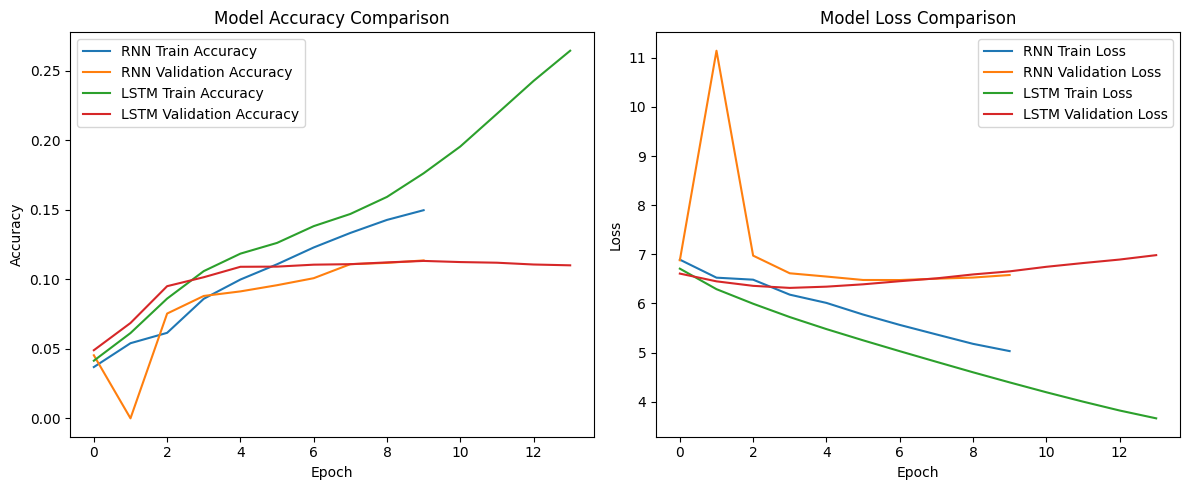

In [ ]:
plt.figure(figsize=(12, 5))

# Plot training & validation accuracy values
plt.subplot(1, 2, 1)
plt.plot(history_rnn.history['accuracy'], label='RNN Train Accuracy')
plt.plot(history_rnn.history['val_accuracy'], label='RNN Validation Accuracy')
plt.plot(history_lstm.history['accuracy'], label='LSTM Train Accuracy')
plt.plot(history_lstm.history['val_accuracy'], label='LSTM Validation Accuracy')
plt.title('Model Accuracy Comparison')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history_rnn.history['loss'], label='RNN Train Loss')
plt.plot(history_rnn.history['val_loss'], label='RNN Validation Loss')
plt.plot(history_lstm.history['loss'], label='LSTM Train Loss')
plt.plot(history_lstm.history['val_loss'], label='LSTM Validation Loss')
plt.title('Model Loss Comparison')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(loc='upper right')

plt.tight_layout()
plt.show()

In [ ]:
lstm_model.save("lstm_model.h5")

In [ ]:
index_to_word = {}
for word, index in word_index.items():
  index_to_word[index] = word

In [ ]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [ ]:
def predictor(model, tokenizer, text, max_len, temperature=1.0):
  text = text.lower()
  seq = tokenizer.texts_to_sequences([text])[0]
  seq = pad_sequences([seq], maxlen=max_len, padding='pre')

  preds = model.predict(seq, verbose=0)[0]

  preds = np.asarray(preds).astype('float64')
  preds = np.log(preds + 1e-10) / temperature
  exp_preds = np.exp(preds)
  preds = exp_preds / np.sum(exp_preds)

  probas = np.random.multinomial(1, preds, 1)[0]
  pred_index = np.argmax(probas)

  return index_to_word.get(pred_index, "")

In [ ]:
seed_text = "what are you"
next_word = predictor(lstm_model,tokenizer,seed_text,max_len)
print(next_word)

are


In [ ]:
def generate_text(model, tokenizer, seed_text, max_len, n_words, temperature=1.0):
  for _ in range(n_words):
    next_word = predictor(model, tokenizer, seed_text, max_len, temperature)
    if next_word == "":
      break
    seed_text += " " + next_word
  return seed_text

In [ ]:
import numpy as np

seed = "what are you"
print(f"Seed text: '{seed}'")

print("\n--- Generating with temperature = 1.0 ---")
generated_text_default = generate_text(lstm_model, tokenizer, seed, max_len, n_words=10, temperature=1.0)
print(generated_text_default)


print("\n--- Generating with temperature = 0.8 ---")
generated_text_high_temp = generate_text(lstm_model, tokenizer, seed, max_len, n_words=10, temperature=0.8)
print(generated_text_high_temp)

print("\n--- Generating with temperature = 1.2 ---")
generated_text_higher_temp = generate_text(lstm_model, tokenizer, seed, max_len, n_words=10, temperature=1.2)
print(generated_text_higher_temp)

Seed text: 'what are you'

--- Generating with temperature = 1.0 ---
what are you grow people in jace and nobody fun at the taste

--- Generating with temperature = 0.8 ---
what are you that is almost arent a schedule to make the first

--- Generating with temperature = 1.2 ---
what are you can windows fall enjoyed to tissue on caesar imagination flash


In [ ]:
seed = "are you a "
generated_text = generate_text(lstm_model,tokenizer,seed,max_len,10)
print(generated_text)

are you a  man of the world you are a man of the


In [ ]:
import pickle
with open("tokenizer.pkl", "wb") as f:
  pickle.dump(tokenizer, f)

In [ ]:
with open("max_len.pkl", "wb") as f:
  pickle.dump(max_len, f)